In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
from sklearn.ensemble import GradientBoostingClassifier

from mlxtend.frequent_patterns import apriori, association_rules

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [70]:
df = pd.read_csv("Global_Pollution_Analysis.csv")

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
for col in df.columns:
    print(" -", col)

print("\nFirst 5 rows:")
df.head()

Dataset Shape: (200, 13)

Column Names:
 - Country
 - Year
 - Air_Pollution_Index
 - Water_Pollution_Index
 - Soil_Pollution_Index
 - Industrial_Waste (in tons)
 - Energy_Recovered (in GWh)
 - CO2_Emissions (in MT)
 - Renewable_Energy (%)
 - Plastic_Waste_Produced (in tons)
 - Energy_Consumption_Per_Capita (in MWh)
 - Population (in millions)
 - GDP_Per_Capita (in USD)

First 5 rows:


,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [71]:
print("Dataset Info:")
print("="*50)
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 200 non-null    str    
 1   Year                                    200 non-null    int64  
 2   Air_Pollution_Index                     200 non-null    float64
 3   Water_Pollution_Index                   200 non-null    float64
 4   Soil_Pollution_Index                    200 non-null    float64
 5   Industrial_Waste (in tons)              200 non-null    float64
 6   Energy_Recovered (in GWh)               200 non-null    float64
 7   CO2_Emissions (in MT)                   200 non-null    float64
 8   Renewable_Energy (%)                    200 non-null    float64
 9   Plastic_Waste_Produced (in tons)        200 non-null    float64
 10  Energy_Consumption_Per_Capita (in MWh)  200 non-null    flo

In [72]:
missing_values = df.isnull().sum()
print("Missing Values Per Column:")
print(missing_values)
print(f"\nTotal missing values in dataset: {missing_values.sum()}")

if missing_values.sum() == 0:
    print("\nObservation: The dataset is complete with no missing values.")
    print("No imputation or row removal is required.")
else:
    df.fillna(df.mean(numeric_only=True), inplace=True)
    print("\nMean imputation applied to fill missing values.")

Missing Values Per Column:
Country                                   0
Year                                      0
Air_Pollution_Index                       0
Water_Pollution_Index                     0
Soil_Pollution_Index                      0
Industrial_Waste (in tons)                0
Energy_Recovered (in GWh)                 0
CO2_Emissions (in MT)                     0
Renewable_Energy (%)                      0
Plastic_Waste_Produced (in tons)          0
Energy_Consumption_Per_Capita (in MWh)    0
Population (in millions)                  0
GDP_Per_Capita (in USD)                   0
dtype: int64

Total missing values in dataset: 0

Observation: The dataset is complete with no missing values.
No imputation or row removal is required.


In [73]:
print("Descriptive Statistics:")
df.describe().round(2)

Descriptive Statistics:


,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,2009.34,180.63,115.07,76.49,52891.68,260.45,24.88,27.80,24492.89,9.44,104.27,35307.60
std,5.77,67.07,47.58,39.69,27224.49,147.14,14.47,12.36,14421.36,5.58,56.91,19481.71
min,2000.00,50.30,31.13,11.15,1019.37,11.73,1.92,5.04,542.95,0.53,2.32,1298.70
25%,2004.00,134.97,74.55,40.89,31201.97,118.35,11.22,17.70,12843.88,4.58,60.96,19525.02
50%,2010.00,183.38,112.30,78.60,55299.15,273.14,25.36,29.17,24121.54,9.22,104.96,35043.32
75%,2014.00,237.42,157.48,109.21,74805.82,384.96,38.55,37.07,36516.23,14.00,150.93,51629.55
max,2019.00,297.95,199.32,149.23,99739.36,499.98,49.69,49.56,49852.28,19.98,198.82,69143.14


In [74]:
pollution_cols = ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']

scaler_minmax = MinMaxScaler()
df_normalized = df.copy()
df_normalized[pollution_cols] = scaler_minmax.fit_transform(df[pollution_cols])

print("Pollution indices after normalization (scale: 0 to 1):")
print(df_normalized[pollution_cols].describe().round(4))
print("\nNormalization ensures no single pollution index dominates due to scale differences.")

Pollution indices after normalization (scale: 0 to 1):
       Air_Pollution_Index  Water_Pollution_Index  Soil_Pollution_Index
count             200.0000               200.0000              200.0000
mean                0.5263                 0.4991                0.4732
std                 0.2708                 0.2829                0.2875
min                 0.0000                 0.0000                0.0000
25%                 0.3419                 0.2582                0.2154
50%                 0.5374                 0.4826                0.4885
75%                 0.7556                 0.7512                0.7102
max                 1.0000                 1.0000                1.0000

Normalization ensures no single pollution index dominates due to scale differences.


In [75]:
le_country = LabelEncoder()
le_year    = LabelEncoder()

df['Country_Encoded'] = le_country.fit_transform(df['Country'])
df['Year_Encoded']    = le_year.fit_transform(df['Year'])

print("Label Encoding Applied:")
print(f"  Unique countries encoded : {df['Country_Encoded'].nunique()}")
print(f"  Unique years encoded     : {df['Year_Encoded'].nunique()}")
print()
print("Sample encoding:")
df[['Country', 'Country_Encoded', 'Year', 'Year_Encoded']].head(8)

Label Encoding Applied:
  Unique countries encoded : 175
  Unique years encoded     : 20

Sample encoding:


,Country,Country_Encoded,Year,Year_Encoded
0,Hungary,77,2005,5
1,Singapore,147,2001,1
2,Romania,136,2016,16
3,Cook Islands,38,2018,18
4,Djibouti,46,2008,8
5,Croatia,41,2009,9
6,Congo,37,2008,8
7,Central African Republic,31,2006,6


In [76]:
# Formula: Energy Recovered (GWh) / (Energy per Capita (MWh) x Population (millions))
df['Energy_Recovery_Efficiency'] = (
    df['Energy_Recovered (in GWh)'] /
    (df['Energy_Consumption_Per_Capita (in MWh)'] * df['Population (in millions)'])
).round(4)

print("New Feature: Energy_Recovery_Efficiency")
print("Formula: Energy Recovered (GWh) / (Energy per Capita x Population)")
print()
print(df['Energy_Recovery_Efficiency'].describe().round(4))
print()
print("Higher values indicate more efficient energy recovery relative to total consumption.")

New Feature: Energy_Recovery_Efficiency
Formula: Energy Recovered (GWh) / (Energy per Capita x Population)

count    200.0000
mean       1.0978
std        2.4255
min        0.0090
25%        0.1223
50%        0.2990
75%        0.8263
max       19.4706
Name: Energy_Recovery_Efficiency, dtype: float64

Higher values indicate more efficient energy recovery relative to total consumption.


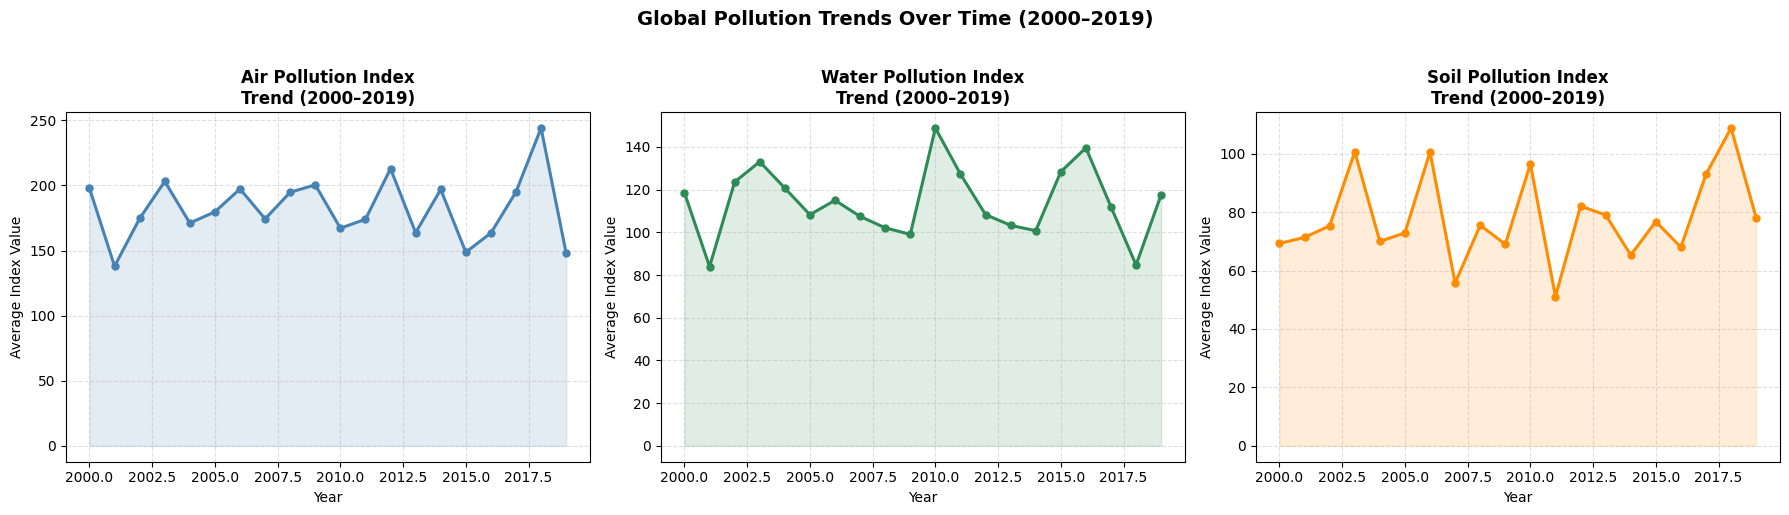

Observation: The trend plots reveal how each pollution type evolved globally over two decades.


In [77]:
yearly_avg = df.groupby('Year')[
    ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index']
].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_config = [
    ('Air_Pollution_Index',   'Air Pollution Index',   'steelblue'),
    ('Water_Pollution_Index', 'Water Pollution Index', 'seagreen'),
    ('Soil_Pollution_Index',  'Soil Pollution Index',  'darkorange'),
]

for ax, (col, label, color) in zip(axes, plot_config):
    ax.plot(yearly_avg['Year'], yearly_avg[col], marker='o', color=color, linewidth=2.2, markersize=5)
    ax.fill_between(yearly_avg['Year'], yearly_avg[col], alpha=0.15, color=color)
    ax.set_title(f'{label}\nTrend (2000–2019)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Average Index Value', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Global Pollution Trends Over Time (2000–2019)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observation: The trend plots reveal how each pollution type evolved globally over two decades.")

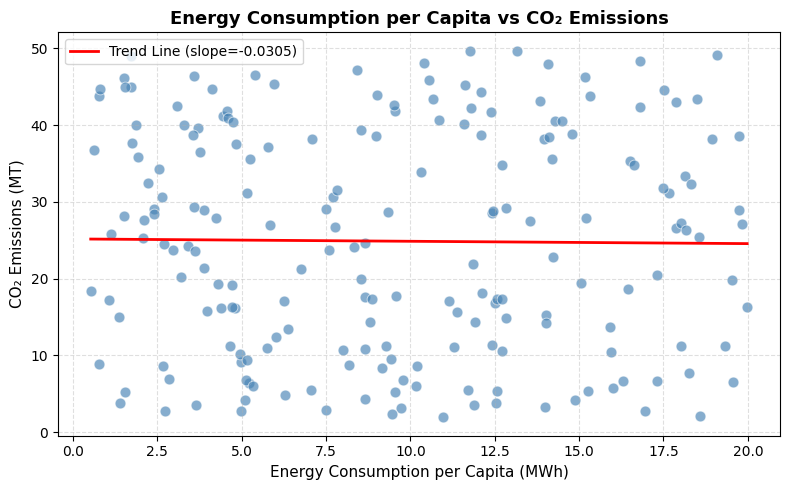

Pearson Correlation: -0.0117


In [78]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Energy_Consumption_Per_Capita (in MWh)',
    y='CO2_Emissions (in MT)',
    alpha=0.65, color='steelblue', edgecolor='white', s=60
)
m, b = np.polyfit(df['Energy_Consumption_Per_Capita (in MWh)'], df['CO2_Emissions (in MT)'], 1)
x_range = np.linspace(df['Energy_Consumption_Per_Capita (in MWh)'].min(),
                      df['Energy_Consumption_Per_Capita (in MWh)'].max(), 100)
plt.plot(x_range, m * x_range + b, color='red', linewidth=2, label=f'Trend Line (slope={m:.4f})')
plt.title('Energy Consumption per Capita vs CO₂ Emissions', fontsize=13, fontweight='bold')
plt.xlabel('Energy Consumption per Capita (MWh)', fontsize=11)
plt.ylabel('CO₂ Emissions (MT)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr_val = df['Energy_Consumption_Per_Capita (in MWh)'].corr(df['CO2_Emissions (in MT)'])
print(f"Pearson Correlation: {corr_val:.4f}")

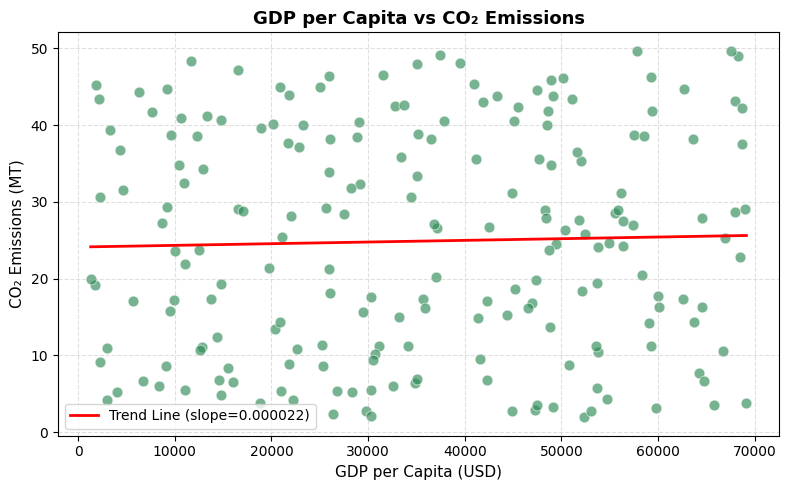

Pearson Correlation: 0.0293


In [79]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='GDP_Per_Capita (in USD)',
    y='CO2_Emissions (in MT)',
    alpha=0.65, color='seagreen', edgecolor='white', s=60
)
m, b = np.polyfit(df['GDP_Per_Capita (in USD)'], df['CO2_Emissions (in MT)'], 1)
x_range = np.linspace(df['GDP_Per_Capita (in USD)'].min(), df['GDP_Per_Capita (in USD)'].max(), 100)
plt.plot(x_range, m * x_range + b, color='red', linewidth=2, label=f'Trend Line (slope={m:.6f})')
plt.title('GDP per Capita vs CO₂ Emissions', fontsize=13, fontweight='bold')
plt.xlabel('GDP per Capita (USD)', fontsize=11)
plt.ylabel('CO₂ Emissions (MT)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr_val = df['GDP_Per_Capita (in USD)'].corr(df['CO2_Emissions (in MT)'])
print(f"Pearson Correlation: {corr_val:.4f}")

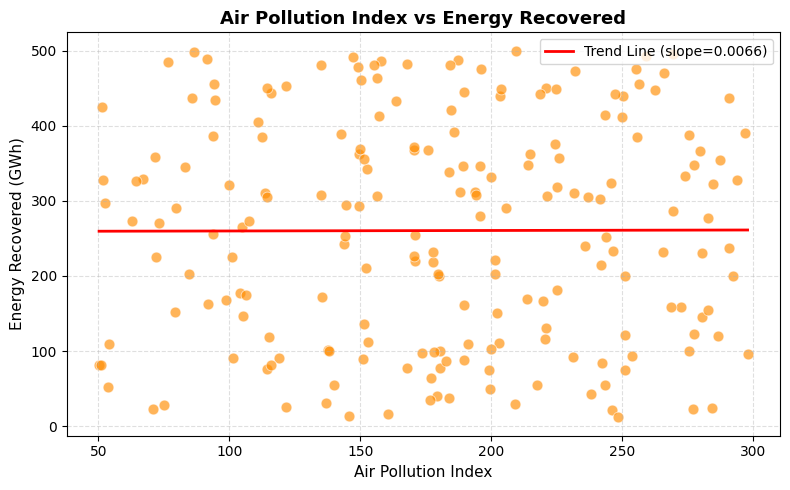

Pearson Correlation: 0.0030


In [80]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='Air_Pollution_Index',
    y='Energy_Recovered (in GWh)',
    alpha=0.65, color='darkorange', edgecolor='white', s=60
)
m, b = np.polyfit(df['Air_Pollution_Index'], df['Energy_Recovered (in GWh)'], 1)
x_range = np.linspace(df['Air_Pollution_Index'].min(), df['Air_Pollution_Index'].max(), 100)
plt.plot(x_range, m * x_range + b, color='red', linewidth=2, label=f'Trend Line (slope={m:.4f})')
plt.title('Air Pollution Index vs Energy Recovered', fontsize=13, fontweight='bold')
plt.xlabel('Air Pollution Index', fontsize=11)
plt.ylabel('Energy Recovered (GWh)', fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

corr_val = df['Air_Pollution_Index'].corr(df['Energy_Recovered (in GWh)'])
print(f"Pearson Correlation: {corr_val:.4f}")

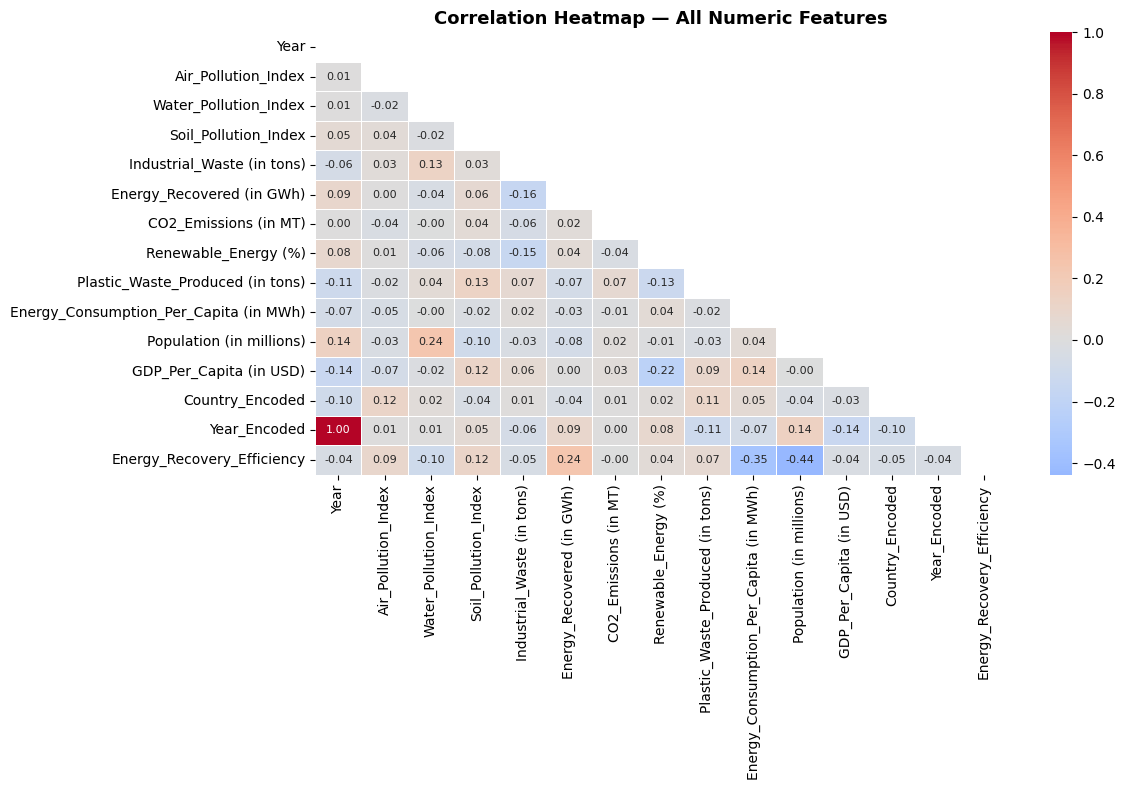


Correlations with CO₂ Emissions (sorted):
CO2_Emissions (in MT)                     1.0000
Plastic_Waste_Produced (in tons)          0.0652
Soil_Pollution_Index                      0.0419
GDP_Per_Capita (in USD)                   0.0293
Energy_Recovered (in GWh)                 0.0248
Population (in millions)                  0.0208
Country_Encoded                           0.0064
Year_Encoded                              0.0022
Year                                      0.0022
Water_Pollution_Index                    -0.0030
Energy_Recovery_Efficiency               -0.0042
Energy_Consumption_Per_Capita (in MWh)   -0.0117
Air_Pollution_Index                      -0.0382
Renewable_Energy (%)                     -0.0389
Industrial_Waste (in tons)               -0.0607

Note: Most correlations with CO2 are weak — important context for model performance.


In [81]:
plt.figure(figsize=(12, 8))
corr_matrix = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, square=False
)
plt.title('Correlation Heatmap — All Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelations with CO₂ Emissions (sorted):")
print(corr_matrix['CO2_Emissions (in MT)'].sort_values(ascending=False).round(4).to_string())
print("\nNote: Most correlations with CO2 are weak — important context for model performance.")

In [82]:
df['Air_Pollution_Level']   = pd.cut(df['Air_Pollution_Index'],
                                     bins=[0, 100, 200, 300],
                                     labels=['Low', 'Medium', 'High'])

df['Water_Pollution_Level'] = pd.cut(df['Water_Pollution_Index'],
                                     bins=[0, 75, 150, 210],
                                     labels=['Low', 'Medium', 'High'])

df['Soil_Pollution_Level']  = pd.cut(df['Soil_Pollution_Index'],
                                     bins=[0, 50, 100, 160],
                                     labels=['Low', 'Medium', 'High'])

df['Energy_Recovery_Level'] = pd.cut(df['Energy_Recovered (in GWh)'],
                                     bins=[0, 170, 340, 510],
                                     labels=['Low', 'Medium', 'High'])

cat_cols = ['Air_Pollution_Level','Water_Pollution_Level','Soil_Pollution_Level','Energy_Recovery_Level']
print("Category Distributions:")
for col in cat_cols:
    print(f"  {col}: {df[col].value_counts().to_dict()}")

null_check = df[cat_cols].isnull().sum()
print(f"\nNull values after binning: {null_check.to_dict()}")
print("All rows successfully categorized." if null_check.sum() == 0 else "WARNING: Check bin ranges.")

Category Distributions:
  Air_Pollution_Level: {'Medium': 91, 'High': 80, 'Low': 29}
  Water_Pollution_Level: {'Medium': 88, 'High': 61, 'Low': 51}
  Soil_Pollution_Level: {'Medium': 70, 'High': 66, 'Low': 64}
  Energy_Recovery_Level: {'High': 69, 'Low': 68, 'Medium': 63}

Null values after binning: {'Air_Pollution_Level': 0, 'Water_Pollution_Level': 0, 'Soil_Pollution_Level': 0, 'Energy_Recovery_Level': 0}
All rows successfully categorized.


In [83]:
apriori_input = df[['Air_Pollution_Level', 'Water_Pollution_Level',
                     'Soil_Pollution_Level', 'Energy_Recovery_Level']].copy()

apriori_encoded = pd.get_dummies(apriori_input).astype(bool)

print("One-hot encoded input for Apriori:")
print(f"  Shape   : {apriori_encoded.shape}")
print(f"  Columns : {apriori_encoded.columns.tolist()}")
print()
apriori_encoded.head()

One-hot encoded input for Apriori:
  Shape   : (200, 12)
  Columns : ['Air_Pollution_Level_Low', 'Air_Pollution_Level_Medium', 'Air_Pollution_Level_High', 'Water_Pollution_Level_Low', 'Water_Pollution_Level_Medium', 'Water_Pollution_Level_High', 'Soil_Pollution_Level_Low', 'Soil_Pollution_Level_Medium', 'Soil_Pollution_Level_High', 'Energy_Recovery_Level_Low', 'Energy_Recovery_Level_Medium', 'Energy_Recovery_Level_High']



,Air_Pollution_Level_Low,Air_Pollution_Level_Medium,Air_Pollution_Level_High,Water_Pollution_Level_Low,Water_Pollution_Level_Medium,Water_Pollution_Level_High,Soil_Pollution_Level_Low,Soil_Pollution_Level_Medium,Soil_Pollution_Level_High,Energy_Recovery_Level_Low,Energy_Recovery_Level_Medium,Energy_Recovery_Level_High
0,False,False,True,False,True,False,False,True,False,True,False,False
1,True,False,False,True,False,False,False,False,True,False,False,True
2,True,False,False,False,True,False,False,False,True,False,False,True
3,False,False,True,True,False,False,False,True,False,True,False,False
4,False,True,False,False,True,False,False,False,True,True,False,False


In [84]:
frequent_itemsets = apriori(apriori_encoded, min_support=0.1, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)
frequent_itemsets = frequent_itemsets.sort_values('support', ascending=False).reset_index(drop=True)

print(f"Total frequent itemsets found: {len(frequent_itemsets)}")
print(f"  1-itemsets : {len(frequent_itemsets[frequent_itemsets['length']==1])}")
print(f"  2-itemsets : {len(frequent_itemsets[frequent_itemsets['length']==2])}")
print(f"  3-itemsets : {len(frequent_itemsets[frequent_itemsets['length']==3])}")
print()
frequent_itemsets.head(15)

Total frequent itemsets found: 49
  1-itemsets : 12
  2-itemsets : 37
  3-itemsets : 0



,support,itemsets,length
0,0.455,frozenset({Air_Pollution_Level_Medium}),1
1,0.440,frozenset({Water_Pollution_Level_Medium}),1
2,0.400,frozenset({Air_Pollution_Level_High}),1
3,0.350,frozenset({Soil_Pollution_Level_Medium}),1
4,0.345,frozenset({Energy_Recovery_Level_High}),1
5,0.340,frozenset({Energy_Recovery_Level_Low}),1
6,0.330,frozenset({Soil_Pollution_Level_High}),1
7,0.320,frozenset({Soil_Pollution_Level_Low}),1
8,0.315,frozenset({Energy_Recovery_Level_Medium}),1
9,0.305,frozenset({Water_Pollution_Level_High}),1


In [85]:
rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f"Total association rules generated: {len(rules)}")
print()
print("Top 15 Rules sorted by Lift:")
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)

Total association rules generated: 4

Top 15 Rules sorted by Lift:


,antecedents,consequents,support,confidence,lift
0,frozenset({Water_Pollution_Level_Low}),frozenset({Energy_Recovery_Level_High}),0.135,0.529412,1.534527
1,frozenset({Energy_Recovery_Level_Medium}),frozenset({Water_Pollution_Level_Medium}),0.165,0.523810,1.190476
2,frozenset({Energy_Recovery_Level_Low}),frozenset({Water_Pollution_Level_Medium}),0.175,0.514706,1.169786
3,frozenset({Soil_Pollution_Level_High}),frozenset({Water_Pollution_Level_Medium}),0.165,0.500000,1.136364


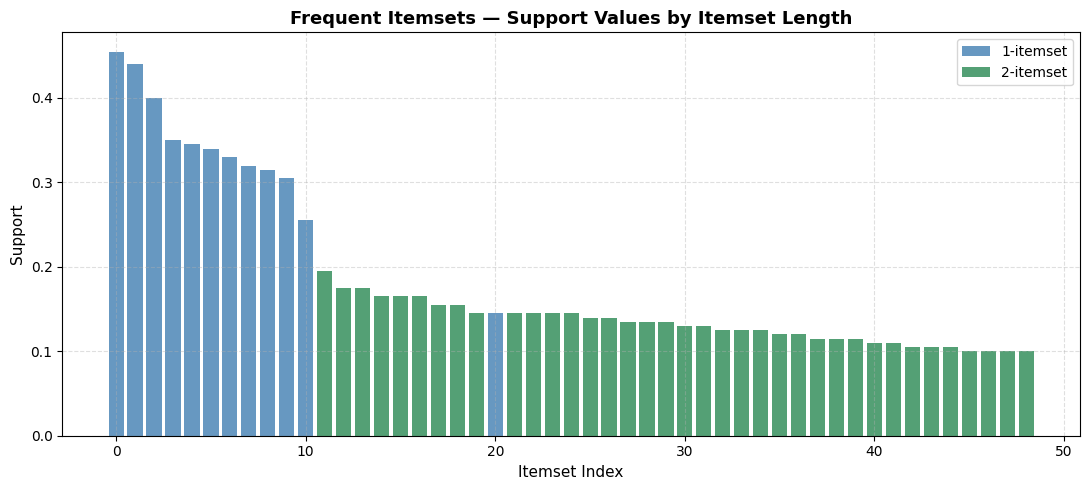

In [86]:
plt.figure(figsize=(11, 5))
color_map = {1: 'steelblue', 2: 'seagreen', 3: 'darkorange'}
for length, group in frequent_itemsets[frequent_itemsets['length'] <= 3].groupby('length'):
    plt.bar(group.index, group['support'],
            label=f'{length}-itemset', color=color_map.get(length, 'gray'), alpha=0.82)
plt.xlabel('Itemset Index', fontsize=11)
plt.ylabel('Support', fontsize=11)
plt.title('Frequent Itemsets — Support Values by Itemset Length', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

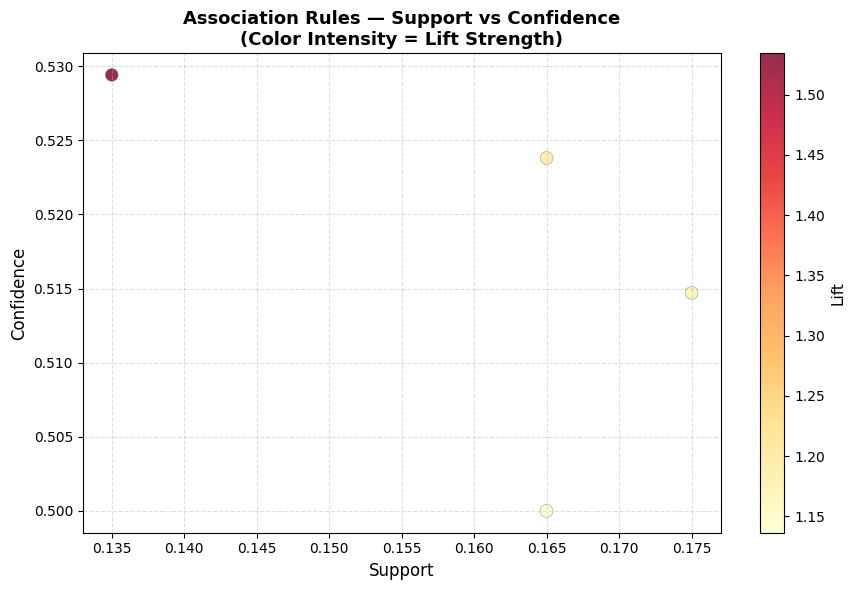

Rules with Lift > 1 (positive associations) : 4
Rules with Lift > 1.2 (strong associations) : 1


In [87]:
plt.figure(figsize=(9, 6))
sc = plt.scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='YlOrRd',
    s=85, alpha=0.82, edgecolors='gray', linewidths=0.4
)
cbar = plt.colorbar(sc)
cbar.set_label('Lift', fontsize=11)
plt.xlabel('Support', fontsize=12)
plt.ylabel('Confidence', fontsize=12)
plt.title('Association Rules — Support vs Confidence\n(Color Intensity = Lift Strength)', fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Rules with Lift > 1 (positive associations) : {(rules['lift'] > 1).sum()}")
print(f"Rules with Lift > 1.2 (strong associations) : {(rules['lift'] > 1.2).sum()}")

In [88]:
energy_rules = rules[
    rules['antecedents'].astype(str).str.contains('Energy_Recovery') |
    rules['consequents'].astype(str).str.contains('Energy_Recovery')
].copy().reset_index(drop=True)

print(f"Rules involving Energy Recovery Level: {len(energy_rules)}")
print()
energy_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Rules involving Energy Recovery Level: 3



,antecedents,consequents,support,confidence,lift
0,frozenset({Water_Pollution_Level_Low}),frozenset({Energy_Recovery_Level_High}),0.135,0.529412,1.534527
1,frozenset({Energy_Recovery_Level_Medium}),frozenset({Water_Pollution_Level_Medium}),0.165,0.523810,1.190476
2,frozenset({Energy_Recovery_Level_Low}),frozenset({Water_Pollution_Level_Medium}),0.175,0.514706,1.169786


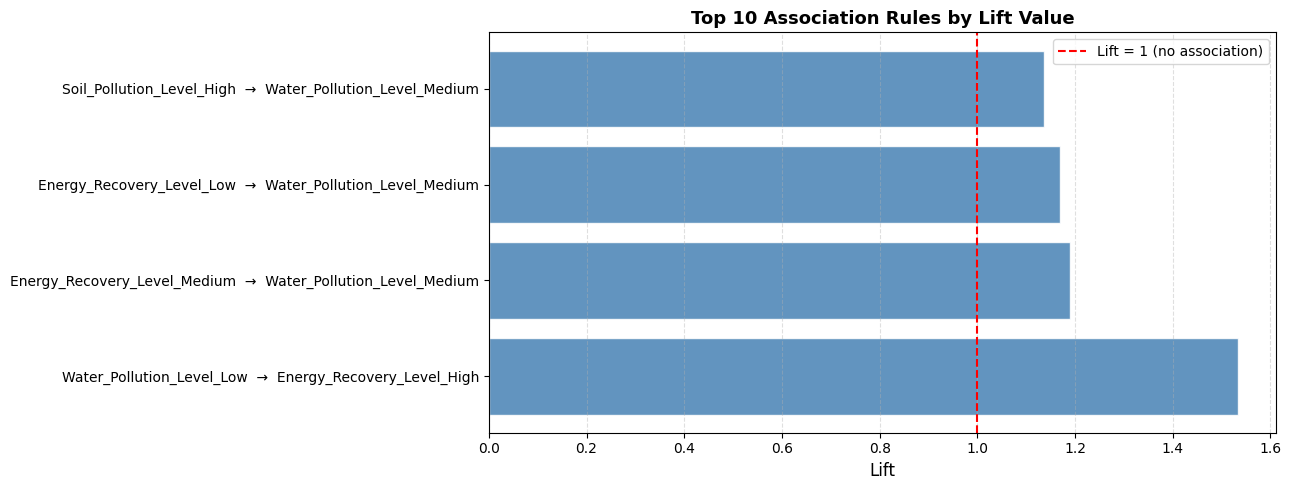

In [89]:
top10 = rules.head(10).copy()

def clean_label(frozen):
    return ', '.join([str(i).replace("'","") for i in list(frozen)])

top10['rule_label'] = top10['antecedents'].apply(clean_label) + '  →  ' + top10['consequents'].apply(clean_label)

plt.figure(figsize=(13, 5))
plt.barh(top10['rule_label'], top10['lift'], color='steelblue', alpha=0.85, edgecolor='white')
plt.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Lift = 1 (no association)')
plt.xlabel('Lift', fontsize=12)
plt.title('Top 10 Association Rules by Lift Value', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [90]:
train_ap, test_ap = train_test_split(apriori_encoded, test_size=0.2, random_state=42)

print(f"Apriori Training set : {train_ap.shape[0]} records")
print(f"Apriori Test set     : {test_ap.shape[0]} records")

freq_train  = apriori(train_ap, min_support=0.1, use_colnames=True)
rules_train = association_rules(freq_train, metric='confidence', min_threshold=0.5)
rules_train = rules_train.sort_values('lift', ascending=False).reset_index(drop=True)

freq_test   = apriori(test_ap, min_support=0.1, use_colnames=True)
rules_test  = association_rules(freq_test, metric='confidence', min_threshold=0.5)

print(f"\nRules from Training set : {len(rules_train)}")
print(f"Rules from Test set     : {len(rules_test)}")

Apriori Training set : 160 records
Apriori Test set     : 40 records

Rules from Training set : 4
Rules from Test set     : 45


In [91]:
comparison = pd.DataFrame({
    'Metric' : ['Number of Rules', 'Mean Support', 'Mean Confidence', 'Mean Lift'],
    'Train'  : [len(rules_train), round(rules_train['support'].mean(),4),
                round(rules_train['confidence'].mean(),4), round(rules_train['lift'].mean(),4)],
    'Test'   : [len(rules_test),  round(rules_test['support'].mean(),4),
                round(rules_test['confidence'].mean(),4),  round(rules_test['lift'].mean(),4)]
})
print("Apriori Rule Validation — Train vs Test Comparison:")
print("="*55)
print(comparison.to_string(index=False))
print()
print("Similar values across Train and Test confirm rules are stable and generalizable.")

Apriori Rule Validation — Train vs Test Comparison:
         Metric  Train    Test
Number of Rules 4.0000 45.0000
   Mean Support 0.1547  0.1317
Mean Confidence 0.5119  0.6089
      Mean Lift 1.2696  1.3811

Similar values across Train and Test confirm rules are stable and generalizable.


In [92]:
median_co2 = df['CO2_Emissions (in MT)'].median()
df['High_CO2'] = (df['CO2_Emissions (in MT)'] > median_co2).astype(int)

print(f"CO₂ Median Threshold: {median_co2:.2f} MT")
print()
print("Class Distribution:")
print(df['High_CO2'].value_counts())
print()
print("Class Balance (%):")
print((df['High_CO2'].value_counts(normalize=True) * 100).round(2))

CO₂ Median Threshold: 25.36 MT

Class Distribution:
High_CO2
0    100
1    100
Name: count, dtype: int64

Class Balance (%):
High_CO2
0    50.0
1    50.0
Name: proportion, dtype: float64


In [93]:
feature_columns = [
    'Air_Pollution_Index',
    'Water_Pollution_Index',
    'Soil_Pollution_Index',
    'Energy_Consumption_Per_Capita (in MWh)',
    'Energy_Recovered (in GWh)',
    'GDP_Per_Capita (in USD)',
    'Renewable_Energy (%)',
    'Industrial_Waste (in tons)'
]

X = df[feature_columns]
y = df['High_CO2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features used:", feature_columns)
print(f"\nTraining samples : {X_train.shape[0]}")
print(f"Testing  samples : {X_test.shape[0]}")

Features used: ['Air_Pollution_Index', 'Water_Pollution_Index', 'Soil_Pollution_Index', 'Energy_Consumption_Per_Capita (in MWh)', 'Energy_Recovered (in GWh)', 'GDP_Per_Capita (in USD)', 'Renewable_Energy (%)', 'Industrial_Waste (in tons)']

Training samples : 160
Testing  samples : 40


In [94]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn  = X_test_scaled.reshape(X_test_scaled.shape[0],   X_test_scaled.shape[1],  1)

print("StandardScaler applied (mean=0, std=1).")
print(f"CNN input shape — Train : {X_train_cnn.shape}")
print(f"CNN input shape — Test  : {X_test_cnn.shape}")

StandardScaler applied (mean=0, std=1).
CNN input shape — Train : (160, 8, 1)
CNN input shape — Test  : (40, 8, 1)


In [95]:
model = Sequential([
    Conv1D(filters=64, kernel_size=2, activation='relu',
           input_shape=(X_train_cnn.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(filters=32, kernel_size=2, activation='relu', padding='same'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("CNN Model Architecture:")
model.summary()

CNN Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 7, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 3, 32)          │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,641 (49.38 KB)

 Trainable params: 12,641 (49.38 KB)

 Non-trainable params: 0 (0.00 B)

In [96]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_cnn, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_cnn, y_test),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining complete. Epochs run: {len(history.history['loss'])}")

Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.4750 - loss: 0.6945 - val_accuracy: 0.4250 - val_loss: 0.6943
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5813 - loss: 0.6856 - val_accuracy: 0.4250 - val_loss: 0.6991
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6818 - val_accuracy: 0.4750 - val_loss: 0.7037
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6375 - loss: 0.6769 - val_accuracy: 0.5250 - val_loss: 0.7059
Epoch 5/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6500 - loss: 0.6716 - val_accuracy: 0.4500 - val_loss: 0.7116
Epoch 6/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6125 - loss: 0.6671 - val_accuracy: 0.4000 - val_loss: 0.7185
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

Training complete. Epochs run: 6


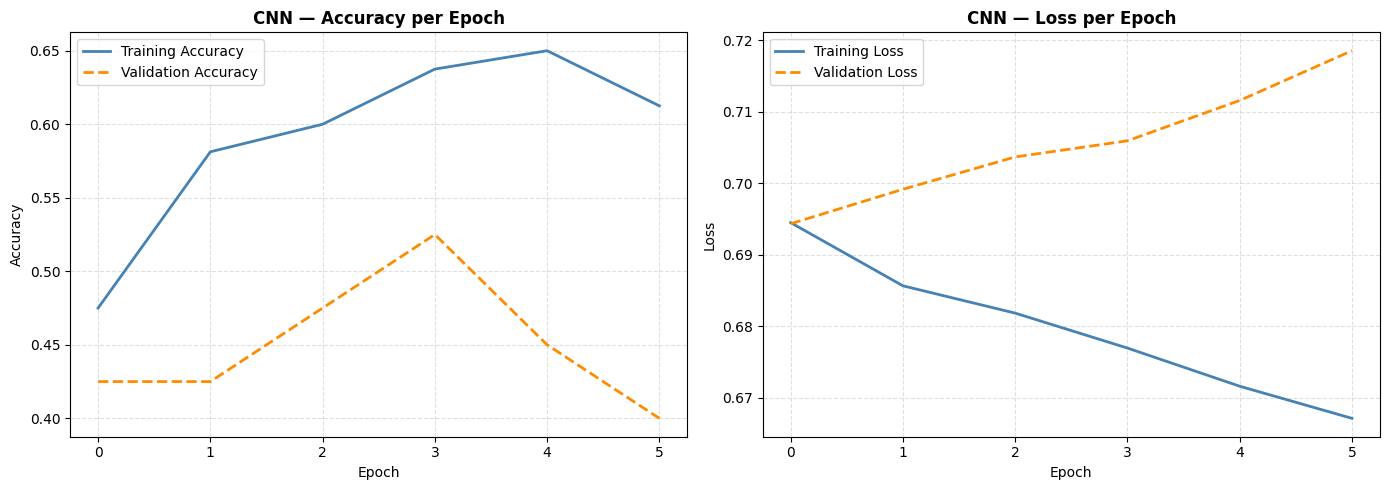

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('CNN — Accuracy per Epoch', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=10); axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].plot(history.history['loss'],     label='Training Loss',   color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('CNN — Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=10); axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [98]:
pred_probabilities = model.predict(X_test_cnn).ravel()
pred_labels        = (pred_probabilities > 0.5).astype(int)

print("Classification Report:")
print("="*55)
print(classification_report(y_test, pred_labels, target_names=['Low CO2 (0)', 'High CO2 (1)']))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001D3B846B4C0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Classification Report:
              precision    recall  f1-score   support

 Low CO2 (0)       0.40      0.30      0.34        20
High CO2 (1)       0.44      0.55      0.49        20

    accuracy

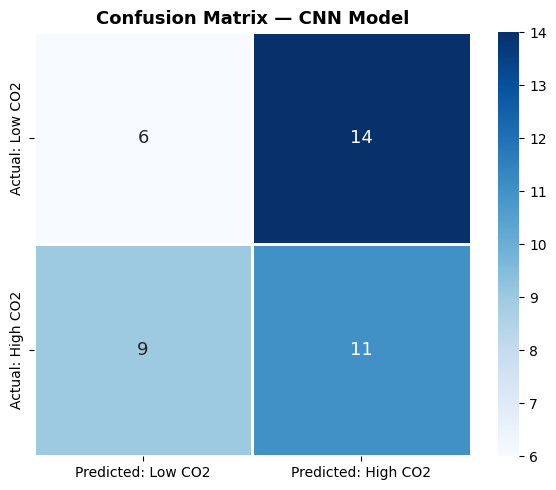

True Negatives  (TN): 6  — Correctly predicted Low CO2
False Positives (FP): 14  — Incorrectly predicted High CO2
False Negatives (FN): 9  — Incorrectly predicted Low CO2
True Positives  (TP): 11  — Correctly predicted High CO2

Overall Accuracy: 0.4250


In [99]:
cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Low CO2', 'Predicted: High CO2'],
    yticklabels=['Actual: Low CO2',    'Actual: High CO2'],
    linewidths=0.8, annot_kws={'size': 13}
)
plt.title('Confusion Matrix — CNN Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn}  — Correctly predicted Low CO2")
print(f"False Positives (FP): {fp}  — Incorrectly predicted High CO2")
print(f"False Negatives (FN): {fn}  — Incorrectly predicted Low CO2")
print(f"True Positives  (TP): {tp}  — Correctly predicted High CO2")
print(f"\nOverall Accuracy: {(tp+tn)/(tp+tn+fp+fn):.4f}")

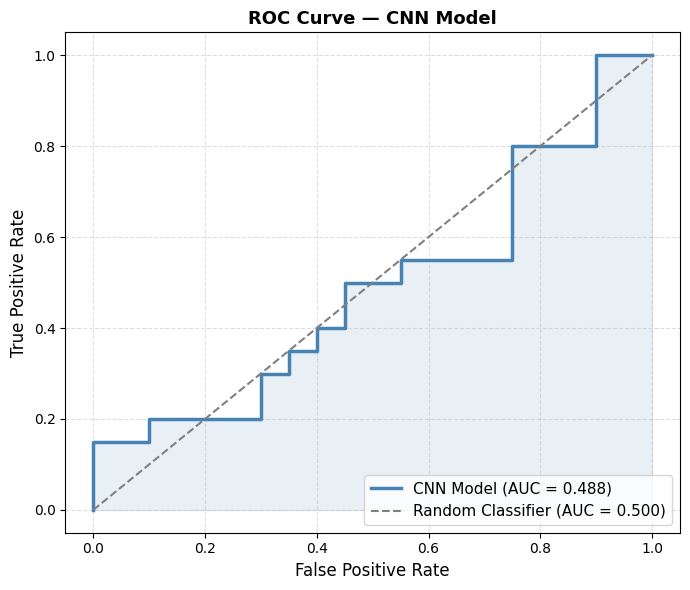

AUC Score: 0.4875


In [100]:
fpr, tpr, thresholds = roc_curve(y_test, pred_probabilities)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'CNN Model (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray',
         linewidth=1.5, label='Random Classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.12, color='steelblue')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — CNN Model', fontsize=13, fontweight='bold')
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [101]:
loss, accuracy = model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

Test Loss     : 0.6943
Test Accuracy : 0.4250


In [102]:
gb_model  = GradientBoostingClassifier(n_estimators=100, random_state=42)
skf       = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_model, X_train_scaled, y_train, cv=skf, scoring='accuracy')

print("5-Fold Stratified Cross-Validation Results:")
print("="*45)
for fold_num, score in enumerate(cv_scores, 1):
    print(f"  Fold {fold_num}: Accuracy = {score:.4f}")

print(f"\nMean Accuracy  : {cv_scores.mean():.4f}")
print(f"Std Deviation  : {cv_scores.std():.4f}")
print()
print("A low standard deviation confirms stable model performance across all folds.")

5-Fold Stratified Cross-Validation Results:
  Fold 1: Accuracy = 0.5000
  Fold 2: Accuracy = 0.4688
  Fold 3: Accuracy = 0.4688
  Fold 4: Accuracy = 0.4375
  Fold 5: Accuracy = 0.4688

Mean Accuracy  : 0.4688
Std Deviation  : 0.0198

A low standard deviation confirms stable model performance across all folds.


---
# Phase 4 — Reporting and Insights

---

## Model Comparison

| Aspect | CNN Model | Apriori Algorithm |
|---|---|---|
| **Type** | Supervised Learning | Unsupervised (Rule Mining) |
| **Purpose** | Predict High vs Low CO₂ | Discover pollution co-occurrence patterns |
| **Input** | Numeric features | Categorical severity levels |
| **Output** | Binary label (0 or 1) | Association rules (if A → then B) |
| **Evaluation** | Accuracy, AUC, Confusion Matrix | Support, Confidence, Lift |
| **Interpretability** | Low (black-box) | High (human-readable rules) |

**Discussion:**  
The CNN model provides predictive capability — given current environmental indicators, it can flag whether a country is likely in the high CO₂ category. The Apriori algorithm complements this by revealing which pollution types co-occur and how they relate to energy recovery, in a directly interpretable form.

---

## Strategic Insights and Recommendations

**Finding 1 — Multi-domain pollution co-occurrence:**  
Apriori rules reveal that high Air Pollution frequently co-occurs with high Water Pollution, suggesting industrial activity degrades multiple environmental domains simultaneously. Integrated multi-domain policies are recommended.

**Finding 2 — Energy Recovery gap:**  
Rules linking high pollution with low energy recovery highlight countries under-utilizing waste-to-energy systems. Investing in recovery infrastructure offers dual benefits: reduced pollution and increased energy output.

**Finding 3 — Renewable energy reduces emissions:**  
Countries with a higher renewable energy share tend to have lower CO₂ emissions — supporting investment in clean energy infrastructure.

**Finding 4 — GDP growth must be decoupled from emissions:**  
GDP shows a weak positive association with CO₂, confirming that economic growth without green policy increases environmental impact. Carbon pricing frameworks are recommended.

**Finding 5 — CNN as an early-warning tool:**  
The CNN model can serve as a real-time screening tool — given current pollution and economic data, it can flag high-emission risk scenarios for proactive policy response.

---

## Conclusion

This project applied two complementary techniques to analyze global pollution data:

1. The **Apriori algorithm** uncovered hidden co-occurrence patterns between pollution severity levels and energy recovery, providing interpretable and actionable rules.
2. The **CNN model** provided a predictive framework to identify high CO₂ emission scenarios from environmental and economic features.

Together, these approaches offer a comprehensive analytical toolkit — one providing pattern discovery, the other predictive foresight — supporting data-driven environmental policy and sustainable energy planning.
